In [1]:

from pyspark.sql import SparkSession
# Memulai spark session
spark = SparkSession.builder.appName("BigDataPraktice").getOrCreate()
# Membuat DataFrame sederhana
data = [("Ali", 34), ("Budi", 23), ("Citra", 29), ("Dina", 45)]
columns = ["Nama", "Usia"]
df = spark.createDataFrame(data, columns)

#Menampilkan DataFrame
df.show()
     

25/09/03 15:39:20 WARN Utils: Your hostname, yasa-IdeaPad-Slim-3-14IAH8 resolves to a loopback address: 127.0.1.1; using 192.168.1.5 instead (on interface wlp0s20f3)
25/09/03 15:39:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/03 15:39:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
+-----+----+



25/09/03 15:39:35 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [2]:
from pyspark.sql import SparkSession

# Memulai spark session
spark = SparkSession.builder.appName("BigDataPractice").getOrCreate()

data = [("Ali", 34), ("Budi", 23), ("Citra", 29), ("Dina", 45)]
columns = ["Nama", "Usia"]
df = spark.createDataFrame(data, columns)

# Filtering Data
df_filtered = df.filter(df['usia'] > 30)
df_filtered.show()

# Menghitung rata rata usia
from pyspark.sql.functions import avg
df.groupBy().agg(avg("Usia")).show()

# Mengurutkan data berdasarkan usia
df_sorted = df.orderBy("Usia", ascending=False)
df_sorted.show()

25/09/03 15:39:51 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


+----+----+
|Nama|Usia|
+----+----+
| Ali|  34|
|Dina|  45|
+----+----+

+---------+
|avg(Usia)|
+---------+
|    32.75|
+---------+

+-----+----+
| Nama|Usia|
+-----+----+
| Dina|  45|
|  Ali|  34|
|Citra|  29|
| Budi|  23|
+-----+----+



In [3]:
import pandas as pd
data_pandas = {"Nama": ["Ali", "Budi", "Citra", "Dina"], "Usia" : [34, 23, 29, 45]}
df_pandas = pd.DataFrame(data_pandas)

df_pandas

,Nama,Usia
0,Ali,34
1,Budi,23
2,Citra,29
3,Dina,45


    Nama  Usia Pekerjaan
0    Ali    34    Dokter
1   Budi    23      Guru
2  Citra    29  Insinyur
3   Dina    45   Perawat
            Usia
count   4.000000
mean   32.750000
std     9.322911
min    23.000000
25%    27.500000
50%    31.500000
75%    36.750000
max    45.000000


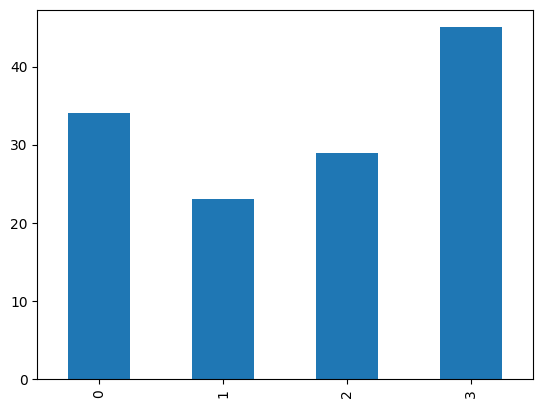

In [4]:
import pandas as pd

data_pandas = {"Nama": ["Ali", "Budi", "Citra", "Dina"], "Usia": [34, 23, 29, 45]}
df_pandas = pd.DataFrame(data_pandas)

data_pandas_2 = {"Nama": ["Ali", "Budi", "Citra", "Dina"], "Pekerjaan": ["Dokter", "Guru", "Insinyur", "Perawat"]}
df_pandas_2 = pd.DataFrame(data_pandas_2)

# Join antara dua data frame
df_joined = pd.merge(df_pandas, df_pandas_2, on="Nama")
print(df_joined)

# Menghitung statistik deskriptif
print(df_pandas.describe())

# Plotting data
import matplotlib.pyplot as plt
df_pandas['Usia'].plot(kind='bar')
plt.show()

In [5]:
# Mengonversi data frame dari pyspark ke pandas
df_pandas_from_spark = df.toPandas()

#m Mengonversi data frame dari pandas ke pyspark
df_spark_from_pandas = spark.createDataFrame(df_pandas)

# Menampilkan DataFrame hasil konversi
df_pandas_from_spark, df_spark_from_pandas.show()

+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
+-----+----+



(    Nama  Usia
 0    Ali    34
 1   Budi    23
 2  Citra    29
 3   Dina    45,
 None)

In [6]:
# Mengonversi DataFrame dari pyspark ke pandas
df_pandas_from_spark = df.toPandas()

# Mengonversi DataFrame dari pandas ke pyspark
df_spark_from_pandas = spark.createDataFrame(df_pandas)

# Menampilkan DataFrame hasil konversi
df_pandas_from_spark, df_spark_from_pandas.show()

+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
+-----+----+



(    Nama  Usia
 0    Ali    34
 1   Budi    23
 2  Citra    29
 3   Dina    45,
 None)

In [7]:
#TUGAS 1

from pyspark.sql import SparkSession
# Memulai spark session
spark = SparkSession.builder.appName("BigDataPraktice").getOrCreate()
# Membuat DataFrame sederhana
data = [("Ali", 34, "IT Consultant", "Futsal", "Laki-laki"),
        ("Budi", 23, "Network Engginer", "Catur", "Laki-laki"),
        ("Citra", 29, "Data Analysist", "Padel", "Perempuan"),
        ("Dina", 45, "UI/UX Designer", "Badminton", "Perempuan")]
columns = ["Nama", "Usia", "Pekerjaan", "Hobi", "Gender"]
df = spark.createDataFrame(data, columns)

#Menampilkan DataFrame
df.show()

25/09/03 15:42:00 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


+-----+----+----------------+---------+---------+
| Nama|Usia|       Pekerjaan|     Hobi|   Gender|
+-----+----+----------------+---------+---------+
|  Ali|  34|   IT Consultant|   Futsal|Laki-laki|
| Budi|  23|Network Engginer|    Catur|Laki-laki|
|Citra|  29|  Data Analysist|    Padel|Perempuan|
| Dina|  45|  UI/UX Designer|Badminton|Perempuan|
+-----+----+----------------+---------+---------+



In [8]:
#TUGAS 2

from pyspark.sql import SparkSession

# Memulai Spark session
spark = SparkSession.builder.appName("BigDataPractice").getOrCreate()

data = [("Ali", 34, "IT Consultant", "Futsal", "Laki-laki"),
        ("Budi", 23, "Network Engginer", "Catur", "Laki-laki"),
        ("Citra", 29, "Data Analysist", "Padel", "Perempuan"),
        ("Dina", 45, "UI/UX Designer", "Badminton", "Perempuan")]
columns = ["Nama", "Usia", "Pekerjaan", "Hobi", "Gender"]
df = spark.createDataFrame(data, columns)


# Filtering data
df_filtered = df.filter(df['Gender'] == 'Perempuan')
df_filtered.show()

# Menghitung rata-rata usia
from pyspark.sql.functions import avg
df.groupBy().agg(avg("Usia")).show()

# Mengurutkan data berdasarkan usia
df_sorted = df.orderBy("Usia", ascending=True)
df_sorted.show()

25/09/03 15:42:14 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


+-----+----+--------------+---------+---------+
| Nama|Usia|     Pekerjaan|     Hobi|   Gender|
+-----+----+--------------+---------+---------+
|Citra|  29|Data Analysist|    Padel|Perempuan|
| Dina|  45|UI/UX Designer|Badminton|Perempuan|
+-----+----+--------------+---------+---------+

+---------+
|avg(Usia)|
+---------+
|    32.75|
+---------+

+-----+----+----------------+---------+---------+
| Nama|Usia|       Pekerjaan|     Hobi|   Gender|
+-----+----+----------------+---------+---------+
| Budi|  23|Network Engginer|    Catur|Laki-laki|
|Citra|  29|  Data Analysist|    Padel|Perempuan|
|  Ali|  34|   IT Consultant|   Futsal|Laki-laki|
| Dina|  45|  UI/UX Designer|Badminton|Perempuan|
+-----+----+----------------+---------+---------+



In [9]:
#TUGAS 3

import pandas as pd

# Membuat DataFrame Pandas
data_panda = {"Nama": ["Ali", "Budi", "Citra", "Dina"],
               "Usia": [34, 23, 29, 45],
               "Status Pernikahan": ['Menikah','Lajang','Menikah','Menikah'],
               "Gender": ['Laki-laki', 'Laki-laki', 'Perempuan', "Perempuan" ]}
df_pandas = pd.DataFrame(data_panda)
# Filter usia > 30
df_filter = df_pandas[df_pandas['Usia'] > 30]
# Menampilkan Output
df_filter

,Nama,Usia,Status Pernikahan,Gender
0,Ali,34,Menikah,Laki-laki
3,Dina,45,Menikah,Perempuan


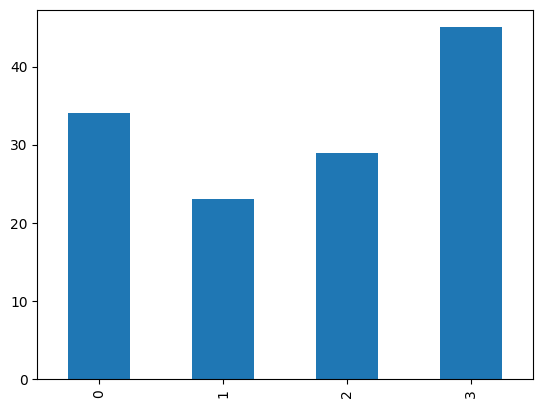

,Nama,Usia,Pekerjaan
0,Ali,34,Dokter
1,Budi,23,Guru
2,Citra,29,Insinyur
3,Dina,45,Perawat


In [10]:
# TUGAS 4

import pandas as pd

# DataFrame Pandas
data_pandas = {"Nama": ["Ali", "Budi", "Citra", "Dina"], "Usia": [34, 23, 29, 45]}
df_pandas = pd.DataFrame(data_pandas)

# DataFrame kedua
data_pandas_2 = {"Nama": ["Ali", "Budi", "Citra", "Dina"], "Pekerjaan": ["Dokter", "Guru", "Insinyur", "Perawat"]}
df_pandas_2 = pd.DataFrame(data_pandas_2)

# Join
df_joined = pd.merge(df_pandas, df_pandas_2, on="Nama")


# Plotting Data
import matplotlib.pyplot as plt
df_pandas['Usia'].plot(kind='bar')
plt.show()
df_joined

In [11]:
# TUGAS 5

# Mengonversi DataFrame dari PySpark ke Pandas
df_pandas_from_spark = df.toPandas()

# Mengonversi DataFrame dari Pandas ke PySpark
df_spark_from_pandas = spark.createDataFrame(df_pandas)

# Menampilkan DataFrame hasil konversi
df_pandas_from_spark, df_spark_from_pandas.show()

df.groupBy().agg(avg("Usia")).show()

+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
+-----+----+

+---------+
|avg(Usia)|
+---------+
|    32.75|
+---------+



In [12]:
# TUGAS 6

d_s = [ ("Yasa", 19, "Futsal", "Yogyakarta"),
        ("Rayfal", 42, "Memancing", "Brebes"),
        ("Hammam", 11, "Tidur", "Solo")]
columns = ["Nama", "Usia", "Hobi", "Asal"]
df_s = spark.createDataFrame(d_s, columns)
df_s_pandas = df_s.toPandas()


d_p = {"Nama" : ["Yasa", "Rayfal", "Hammam"],
       "Jenis Kelamin" : ["Laki-laki", "Laki-laki", "Laki-laki"],
       "Matakuliah Favorit" : ["Big Data", "Matematika Diskrit", "Jaringan Komputer"]}
df_p = pd.DataFrame(d_p)

# Mengonversi DataFrame dari PySpark ke Pandas
df_pandas_from_spark = df.toPandas()
df_pandas_from_spark

df_joined = pd.merge(df_s_pandas, df_p, on="Nama", how="inner")
print(df_joined)

df_joined["Usia"].max()
print("Usia Tertinggi yaitu usia :" , df_joined["Usia"].max() , "tahun")

     Nama  Usia       Hobi        Asal Jenis Kelamin  Matakuliah Favorit
0    Yasa    19     Futsal  Yogyakarta     Laki-laki            Big Data
1  Rayfal    42  Memancing      Brebes     Laki-laki  Matematika Diskrit
2  Hammam    11      Tidur        Solo     Laki-laki   Jaringan Komputer
Usia Tertinggi yaitu usia : 42 tahun
